# Import libraries

In [106]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [107]:
c = 299792458 * 10**(-3)
H0 = 75
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)

# Some key functions

In [ ]:
#order of variables: z, k, omega_M, omega_DE, LPeakLambda, rc

def scale_factor(z):
    return 1/(1+z)

def Friedmann_eq(z, omega_DE):
    a = scale_factor(z)
    omega_M = 1 - omega_DE
    H2 = (H0**2)*(omega_M/(a**3) + omega_DE)
    return np.sqrt(H2)

def integrand(z, omega_DE):
    return c/Friedmann_eq(z, omega_DE)

def co_moving_dist(z_up, omega_DE):
    dist_c = []
    for zval in z_up:
        dist, err = scp.integrate.quad(integrand, 0, zval, args = (omega_DE))
        dist_c.append(dist)   
    return np.array(dist_c)

def mag_model(z, omega_DE, LPeakLambda):
    rc = co_moving_dist(z, omega_DE)
    flux = (1e32)*LPeakLambda/(4*np.pi*((rc*(1+z))**2))
    argument = flux/f0
    mag = -2.5*np.log10(argument)
    return mag

# Load the data

In [109]:
sn_z, sn_mag, sn_mag_err = np.loadtxt("sn_data.txt", usecols=(1,2,3), unpack = True)

In [140]:
#print(sn_z)
#print(co_moving_dist(sn_z, 0.7))
print(mag_model(sn_z, 0.7, 3))

<class 'numpy.ndarray'>
[22.93594905 22.27547991 22.742858   22.41530081 22.71239848 22.40163264
 22.44243635 22.90753842 22.97524431 23.15339288 23.87332707 22.58711164
 23.70675758 23.05763145 22.89035215 22.50913471 23.50666916 23.11123676
 23.13765874 23.87736653 24.49713151 22.89035215 22.77298794 23.55238729
 24.27887359 23.29612681 20.49523056 23.72386891 23.60628021 23.41292778
 20.60443217 22.41530081 23.01399423 22.77298794 23.88140015 23.69385493
 22.02018718 23.54784897 22.89035215 23.55691826 22.68778857 24.50358116
 16.49625395 17.6372383  16.17905457 18.55610123 16.17905457 14.81521977
 19.24091448 15.59957684 16.9017795  17.40060193 17.2987261  15.36751661
 18.67494859 18.92264258 18.15923479 18.43103391 17.72552869 17.6372383 ]


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE, LPeakLambda}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [110]:
def log_prior(theta):
    omega_DE, LPeakLambda = theta
    if 0<omega_DE<1 and 0<LPeakLambda<10:
        return 0.0
    return -np.inf

priors_central = [0.5, 5]
    

# Likelihood function

In [111]:
def log_likelihood(theta, z, mag, magerr):
    omega_DE, LPeakLambda = theta
    model = mag_model(z, omega_DE, LPeakLambda)
    return -0.5*np.sum(((mag - model)**2)/(magerr**2))


def log_probability(theta, z, mag, magerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mag, magerr)


In [147]:
soln = scp.optimize.minimize(lambda theta: -log_probability(theta, sn_z, sn_mag, sn_mag_err), [0.2, 4])

#print(soln.x)
#print(soln)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.nd

C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\optimize\_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\optimize\_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.nd

# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [ ]:
pos = priors_central + 0.5*np.random.rand(32, 2)
nsteps = 5000 #number of steps walkers take
ndiscard = 10 #how many steps at the beginning of the chain to discard
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mag, sn_mag_err)
)
sampler.run_mcmc(pos, nsteps, progress = True)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


  0%|          | 0/5000 [00:00<?, ?it/s]

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


  0%|          | 2/5000 [00:00<16:47,  4.96it/s]

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


...

 94%|█████████▎| 4687/5000 [10:42<00:48,  6.49it/s]

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
emcee: Exception while calling your like

Traceback (most recent call last):
  File "C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_30740\3573389450.py", line 11, in log_probability
    return lp + log_likelihood(theta, z, mag, magerr)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_30740\3573389450.py", line 3, in log_likelihood
    model = mag_model(z, omega_DE, LPeakLambda)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_30740\3380244037.py", line 23, in mag_model
    rc = co_moving_dist(z, omega_DE)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_30740\3380244037.py", line 18, in co_moving_dist
   

(array([0.458, 0.354, 0.425, 0.374, 0.42 , 0.372, 0.378, 0.453, 0.465,
       0.498, 0.655, 0.4  , 0.615, 0.48 , 0.45 , 0.388, 0.57 , 0.49 ,
       0.495, 0.656, 0.828, 0.45 , 0.43 , 0.58 , 0.763, 0.526, 0.172,
       0.619, 0.592, 0.55 , 0.18 , 0.374, 0.472, 0.43 , 0.657, 0.612,
       0.32 , 0.579, 0.45 , 0.581, 0.416, 0.83 , 0.03 , 0.05 , 0.026,
       0.075, 0.026, 0.014, 0.101, 0.02 , 0.036, 0.045, 0.043, 0.018,
       0.079, 0.088, 0.063, 0.071, 0.052, 0.05 ]), array([23.11, 22.38, 22.13, 21.72, 22.55, 22.26, 22.58, 23.17, 23.33,
       23.71, 23.27, 22.36, 23.19, 22.96, 22.51, 22.65, 23.27, 23.1 ,
       22.83, 23.57, 24.65, 23.17, 23.13, 23.46, 24.47, 23.15, 20.17,
       23.8 , 24.42, 23.51, 20.43, 23.52, 23.11, 22.57, 23.83, 23.69,
       21.86, 23.48, 22.83, 23.09, 22.57, 24.32, 16.26, 17.63, 16.08,
       18.43, 16.28, 14.47, 19.16, 15.18, 16.66, 17.61, 17.19, 15.61,
       18.27, 19.28, 18.24, 18.33, 17.54, 17.69]), array([0.46, 0.33, 0.49, 0.22, 0.25, 0.2 , 0.37, 0.25, 0.

KeyboardInterrupt: 

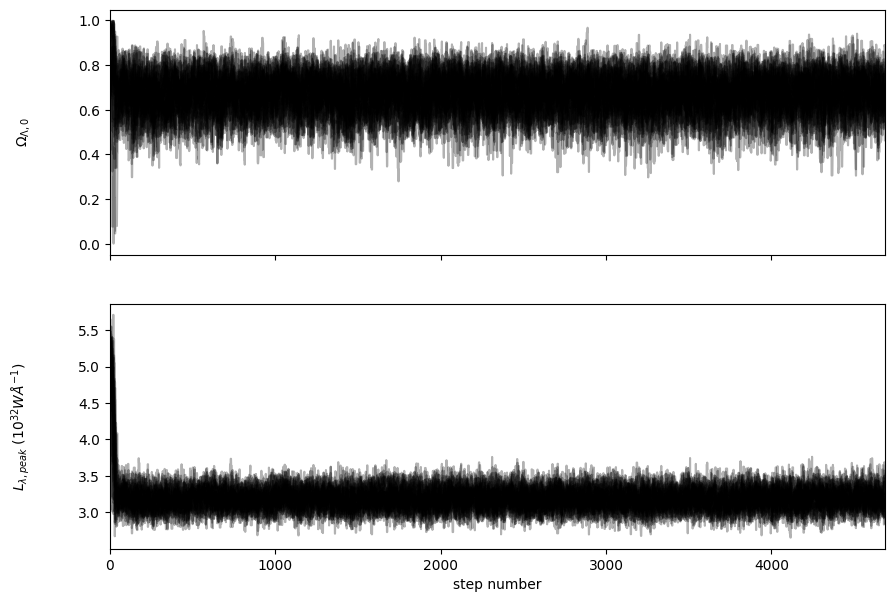

In [151]:
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["${Ω_{Λ,0}}$", "${L_{λ, peak}}$ ${(10^{32} W Å^{-1})}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

# Covariance plots

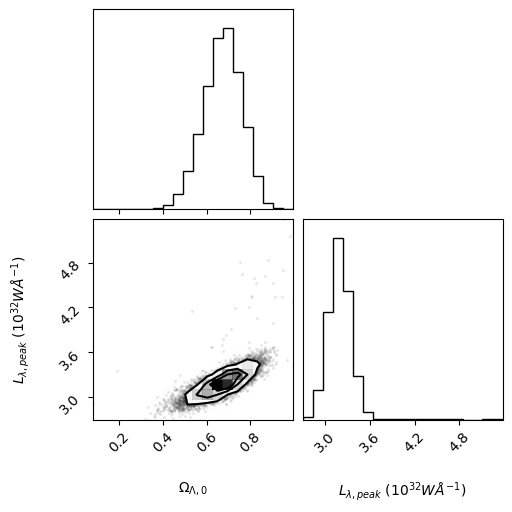

In [152]:

fig = corner.corner(
    flat_samples, labels = labels
)
plt.savefig("corner.png")

In [153]:


for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [34, 50, 68])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]}, {q[0]}, {q[1]}")

${Ω_{Λ,0}}$: 0.6739841035025853, 0.03622039324871584, 0.0397410054211359
${L_{λ, peak}}$ ${(10^{32} W Å^{-1})}$: 3.1839571797340636, 0.05873037634716871, 0.06669176564491952
